# CNN-LOB: Convolutional Neural Networks for Limit Order Books

### Based on: Tsantekidis et al. (2017) "Forecasting Stock Prices from the Limit Order Book using Convolutional Neural Networks"

This notebook implements the CNN architecture from the 2017 paper and trains it on the FI-2010 dataset.
The data loading follows the same approach as the DeepLOB notebook.

### Architecture (from paper Section V):
1. **Conv2D**: 16 filters, kernel (4, 40) — scans full feature width with temporal window of 4
2. **Conv2D**: 16 filters, kernel (4, 1) — temporal convolution (Conv1D equivalent)
3. **MaxPool2D**: (2, 1)
4. **Conv2D**: 32 filters, kernel (3, 1)
5. **Conv2D**: 32 filters, kernel (3, 1)
6. **MaxPool2D**: (2, 1)
7. **Dense**: 32 neurons, LeakyReLU
8. **Dense**: 3 neurons, Softmax

**Activations:** LeakyReLU on all conv + first dense; Softmax on output.

### References:
[1] Ntakaris A, et al. Benchmark dataset for mid-price forecasting of limit order book data. Journal of Forecasting. 2018.

[2] Tsantekidis A, et al. Forecasting Stock Prices from the Limit Order Book using Convolutional Neural Networks. CBI 2017.

In [1]:
# Data is already extracted in ../data/extracted/
import os
data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data', 'extracted')
# Fallback: if running from the notebook's own directory
if not os.path.isdir(data_dir):
    data_dir = os.path.join('..', 'data', 'extracted')
print(f"Data directory: {data_dir}")
print("Files:", os.listdir(data_dir))

Data directory: c:\Users\mateu\DeepLOB\data\extracted
Files: ['Test_Dst_NoAuction_DecPre_CF_7.txt', 'Test_Dst_NoAuction_DecPre_CF_8.txt', 'Test_Dst_NoAuction_DecPre_CF_9.txt', 'Train_Dst_NoAuction_DecPre_CF_7.txt']


In [2]:
# limit gpu memory
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found, using CPU")

TensorFlow version: 2.21.0
No GPU found, using CPU


In [3]:
# load packages
import numpy as np
import keras
from keras.models import Model
from keras.layers import Flatten, Dense, Input, Conv2D, MaxPooling2D, LeakyReLU
from keras.optimizers import Adam
from keras.utils import to_categorical

from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# set random seeds
np.random.seed(1)
tf.random.set_seed(2)

# Data preparation

We use the no-auction dataset normalised by decimal precision. The first 40 columns are 10 levels of ask and bid information (price + volume) and we use these 40 features. The last 5 columns are labels with different prediction horizons.

In [4]:
def prepare_x(data):
    df1 = data[:40, :].T
    return np.array(df1)

def get_label(data):
    lob = data[-5:, :].T
    return lob

def data_classification(X, Y, T):
    [N, D] = X.shape
    df = np.array(X)
    dY = np.array(Y)
    dataY = dY[T - 1:N]
    dataX = np.zeros((N - T + 1, T, D))
    for i in range(T, N + 1):
        dataX[i - T] = df[i - T:i, :]
    return dataX.reshape(dataX.shape + (1,)), dataY

def prepare_x_y(data, k, T):
    x = prepare_x(data)
    y = get_label(data)
    x, y = data_classification(x, y, T=T)
    y = y[:,k] - 1
    y = to_categorical(y, 3)
    return x, y

In [5]:
dec_data = np.loadtxt(os.path.join(data_dir, 'Train_Dst_NoAuction_DecPre_CF_7.txt'))
dec_train = dec_data[:, :int(np.floor(dec_data.shape[1] * 0.8))]
dec_val = dec_data[:, int(np.floor(dec_data.shape[1] * 0.8)):]

dec_test1 = np.loadtxt(os.path.join(data_dir, 'Test_Dst_NoAuction_DecPre_CF_7.txt'))
dec_test2 = np.loadtxt(os.path.join(data_dir, 'Test_Dst_NoAuction_DecPre_CF_8.txt'))
dec_test3 = np.loadtxt(os.path.join(data_dir, 'Test_Dst_NoAuction_DecPre_CF_9.txt'))
dec_test = np.hstack((dec_test1, dec_test2, dec_test3))

k = 1  # prediction horizon (index into label columns: 0=k10, 1=k20, 2=k30, 3=k50, 4=k100)
T = 100  # the length of a single input (100 timesteps)
checkpoint_filepath = './model_cnnlob_2017/weights'

trainX_CNN, trainY_CNN = prepare_x_y(dec_train, k, T)
valX_CNN, valY_CNN = prepare_x_y(dec_val, k, T)
testX_CNN, testY_CNN = prepare_x_y(dec_test, k, T)

print(trainX_CNN.shape, trainY_CNN.shape)
print(valX_CNN.shape, valY_CNN.shape)
print(testX_CNN.shape, testY_CNN.shape)

(203701, 100, 40, 1) (203701, 3)
(50851, 100, 40, 1) (50851, 3)
(139488, 100, 40, 1) (139488, 3)


# Model Architecture

CNN architecture from Tsantekidis et al. (2017).

The first Conv2D layer uses a (4, 40) kernel that spans the full feature width, collapsing it to 1.
All subsequent convolutions operate as temporal (1D) convolutions using Conv2D with width=1 kernels.
This produces a tensor of shape (batch, time, 1, channels) throughout.

In [6]:
def create_cnnlob(T, NF):
    """CNN-LOB architecture from Tsantekidis et al. (2017).
    
    Args:
        T: number of timesteps (100)
        NF: number of features (40)
    """
    input_lmd = Input(shape=(T, NF, 1))
    
    # Layer 1: Conv2D 16 filters, kernel (4, 40) - spans full feature width
    x = Conv2D(16, (4, NF), padding='valid')(input_lmd)
    x = LeakyReLU(negative_slope=0.01)(x)
    
    # Layer 2: Conv2D 16 filters, kernel (4, 1) - temporal convolution
    x = Conv2D(16, (4, 1), padding='valid')(x)
    x = LeakyReLU(negative_slope=0.01)(x)
    
    # Layer 3: MaxPool (2, 1)
    x = MaxPooling2D(pool_size=(2, 1))(x)
    
    # Layer 4: Conv2D 32 filters, kernel (3, 1)
    x = Conv2D(32, (3, 1), padding='valid')(x)
    x = LeakyReLU(negative_slope=0.01)(x)
    
    # Layer 5: Conv2D 32 filters, kernel (3, 1)
    x = Conv2D(32, (3, 1), padding='valid')(x)
    x = LeakyReLU(negative_slope=0.01)(x)
    
    # Layer 6: MaxPool (2, 1)
    x = MaxPooling2D(pool_size=(2, 1))(x)
    
    # Flatten for dense layers
    x = Flatten()(x)
    
    # Layer 7: Dense 32 neurons
    x = Dense(32)(x)
    x = LeakyReLU(negative_slope=0.01)(x)
    
    # Layer 8: Dense 3 neurons (output)
    out = Dense(3, activation='softmax')(x)
    
    model = Model(inputs=input_lmd, outputs=out)
    adam = Adam(learning_rate=0.001)
    model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

cnnlob = create_cnnlob(trainX_CNN.shape[1], trainX_CNN.shape[2])
cnnlob.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 40, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 97, 1, 16)      │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 97, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 94, 1, 16)      │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 94, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 1, 32)      │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 45, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 43, 1, 32)      │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 43, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 21, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 672)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        21,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,923 (116.89 KB)

 Trainable params: 29,923 (116.89 KB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [7]:
%%time

os.makedirs('./model_cnnlob_2017', exist_ok=True)
checkpoint_filepath = './model_cnnlob_2017/weights.weights.h5'

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True)

history = cnnlob.fit(trainX_CNN, trainY_CNN, validation_data=(valX_CNN, valY_CNN), 
                     epochs=100, batch_size=16, verbose=2,
                     callbacks=[model_checkpoint_callback, early_stop])

Epoch 1/100
12732/12732 - 53s - 4ms/step - accuracy: 0.4861 - loss: 1.0467 - val_accuracy: 0.5265 - val_loss: 1.0257
Epoch 2/100
12732/12732 - 76s - 6ms/step - accuracy: 0.4861 - loss: 1.0446 - val_accuracy: 0.5265 - val_loss: 1.0269
Epoch 3/100
12732/12732 - 66s - 5ms/step - accuracy: 0.4861 - loss: 1.0439 - val_accuracy: 0.5265 - val_loss: 1.0274
Epoch 4/100
12732/12732 - 44s - 3ms/step - accuracy: 0.4861 - loss: 1.0430 - val_accuracy: 0.5265 - val_loss: 1.0218
Epoch 5/100
12732/12732 - 37s - 3ms/step - accuracy: 0.4862 - loss: 1.0379 - val_accuracy: 0.5265 - val_loss: 1.0237
Epoch 6/100
12732/12732 - 32s - 3ms/step - accuracy: 0.4896 - loss: 1.0275 - val_accuracy: 0.5265 - val_loss: 1.0208
Epoch 7/100
12732/12732 - 30s - 2ms/step - accuracy: 0.4892 - loss: 1.0266 - val_accuracy: 0.5265 - val_loss: 1.0212
Epoch 8/100
12732/12732 - 30s - 2ms/step - accuracy: 0.4896 - loss: 1.0236 - val_accuracy: 0.5265 - val_loss: 1.0184
Epoch 9/100
12732/12732 - 31s - 2ms/step - accuracy: 0.4918 - lo

# Model Testing

In [8]:
cnnlob.load_weights(checkpoint_filepath)
pred = cnnlob.predict(testX_CNN)

4359/4359 ━━━━━━━━━━━━━━━━━━━━ 4s 981us/step


In [9]:
print('accuracy_score:', accuracy_score(np.argmax(testY_CNN, axis=1), np.argmax(pred, axis=1)))
print(classification_report(np.argmax(testY_CNN, axis=1), np.argmax(pred, axis=1), digits=4))

accuracy_score: 0.6111851915576967
              precision    recall  f1-score   support

           0     0.3215    0.0888    0.1392     27425
           1     0.6405    0.9438    0.7631     86588
           2     0.2537    0.0429    0.0735     25475

    accuracy                         0.6112    139488
   macro avg     0.4052    0.3585    0.3252    139488
weighted avg     0.5071    0.6112    0.5145    139488



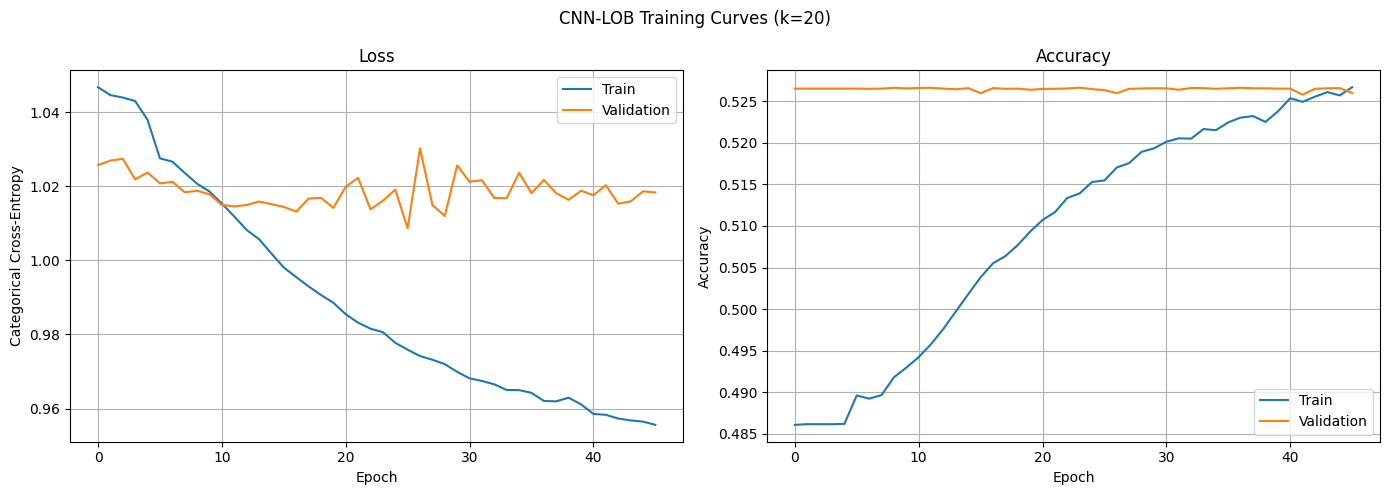

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train')
ax1.plot(history.history['val_loss'], label='Validation')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Categorical Cross-Entropy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['accuracy'], label='Train')
ax2.plot(history.history['val_accuracy'], label='Validation')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.suptitle('CNN-LOB Training Curves (k=20)')
plt.tight_layout()
plt.show()